# Clinical Disease Analysis — Combined Notebook

This notebook combines the complete original notebooks in the following order:
1. Asthma
2. IPF
3. Pneumonia
4. COPD


---
# SECTION 1 — ASTHMA
All cells from the original **ASTHMA** notebook are included below.


In [2]:
from google.colab import files
uploaded = files.upload()

In [3]:
!pip install -q xgboost catboost imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())
print(df.columns)
print("Dataset Shape:", df.shape)
print()

df.head()


   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       5034   63       0          1               0  15.848744        0   
1       5035   26       1          2               2  22.757042        0   
2       5036   57       0          2               1  18.395396        0   
3       5037   40       1          2               1  38.515278        0   
4       5038   61       0          0               3  19.283802        0   

   PhysicalActivity  DietQuality  SleepQuality  ...  LungFunctionFEV1  \
0          0.894448     5.488696      8.701003  ...          1.369051   
1          5.897329     6.341014      5.153966  ...          2.197767   
2          6.739367     9.196237      6.840647  ...          1.698011   
3          1.404503     5.826532      4.253036  ...          3.032037   
4          4.604493     3.127048      9.625799  ...          3.470589   

   LungFunctionFVC  Wheezing  ShortnessOfBreath  ChestTightness  Coughing  \
0         4.941206         

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,PhysicalActivity,DietQuality,SleepQuality,...,LungFunctionFEV1,LungFunctionFVC,Wheezing,ShortnessOfBreath,ChestTightness,Coughing,NighttimeSymptoms,ExerciseInduced,Diagnosis,DoctorInCharge
0,5034,63,0,1,0,15.848744,0,0.894448,5.488696,8.701003,...,1.369051,4.941206,0,0,1,0,0,1,0,Dr_Confid
1,5035,26,1,2,2,22.757042,0,5.897329,6.341014,5.153966,...,2.197767,1.702393,1,0,0,1,1,1,0,Dr_Confid
2,5036,57,0,2,1,18.395396,0,6.739367,9.196237,6.840647,...,1.698011,5.022553,1,1,1,0,1,1,0,Dr_Confid
3,5037,40,1,2,1,38.515278,0,1.404503,5.826532,4.253036,...,3.032037,2.300159,1,0,1,1,1,0,0,Dr_Confid
4,5038,61,0,0,3,19.283802,0,4.604493,3.127048,9.625799,...,3.470589,3.067944,1,1,1,0,0,1,0,Dr_Confid


In [5]:
features = [
    "Age",
    "Gender",
    "Wheezing",
    "HistoryOfAllergies",
    "Smoking",
    "LungFunctionFEV1",
    "FamilyHistoryAsthma",
    "ShortnessOfBreath"
]

target = "Diagnosis"

X = df[features]
y = df[target]

In [6]:
print("Dataset Info:")
print(df.info())

print("\nNull Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns.tolist())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2392 non-null   int64  
 1   Age                     2392 non-null   int64  
 2   Gender                  2392 non-null   int64  
 3   Ethnicity               2392 non-null   int64  
 4   EducationLevel          2392 non-null   int64  
 5   BMI                     2392 non-null   float64
 6   Smoking                 2392 non-null   int64  
 7   PhysicalActivity        2392 non-null   float64
 8   DietQuality             2392 non-null   float64
 9   SleepQuality            2392 non-null   float64
 10  PollutionExposure       2392 non-null   float64
 11  PollenExposure          2392 non-null   float64
 12  DustExposure            2392 non-null   float64
 13  PetAllergy              2392 non-null   int64  
 14  FamilyHistoryAsthma     23

In [7]:
print("Diagnosis Value Counts:")
print(df["Diagnosis"].value_counts())

print("\nDiagnosis Percentage:")
print(df["Diagnosis"].value_counts(normalize=True) * 100)

Diagnosis Value Counts:
Diagnosis
0    2268
1     124
Name: count, dtype: int64

Diagnosis Percentage:
Diagnosis
0    94.816054
1     5.183946
Name: proportion, dtype: float64


In [8]:
# ==========================
# Train-test split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nBefore SMOTE:")
print(y_train.value_counts())


Before SMOTE:
Diagnosis
0    1814
1      99
Name: count, dtype: int64


In [9]:
# ==========================
# XGBoost imbalance weight
# ==========================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [10]:
from imblearn.over_sampling import ADASYN
# ==========================
# Models with SMOTE
# ==========================

models = {
    "Logistic Regression": ImbPipeline([
        ("SMOTE", ADASYN(random_state=42)),
        ("Scaler", StandardScaler()),
        ("Model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": ImbPipeline([
        ("SMOTE", ADASYN(random_state=42)),
        ("Model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "XGBoost": ImbPipeline([
        ("SMOTE", ADASYN(random_state=42)),
        ("Model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss"
        ))
    ]),

    "CatBoost": ImbPipeline([
        ("SMOTE", ADASYN(random_state=42)),
        ("Model", CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            class_weights=[1, scale_pos_weight],
            random_state=42,
            verbose=False
        ))
    ])
}


MODEL: Logistic Regression
Training completed.


Threshold : 0.2
Accuracy  : 0.2902
Precision : 0.0637
Recall    : 0.9200
F1 Score  : 0.1192
ROC-AUC   : 0.5877

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.26      0.41       454
           1       0.06      0.92      0.12        25

    accuracy                           0.29       479
   macro avg       0.52      0.59      0.26       479
weighted avg       0.94      0.29      0.39       479


Confusion Matrix:
[[116 338]
 [  2  23]]


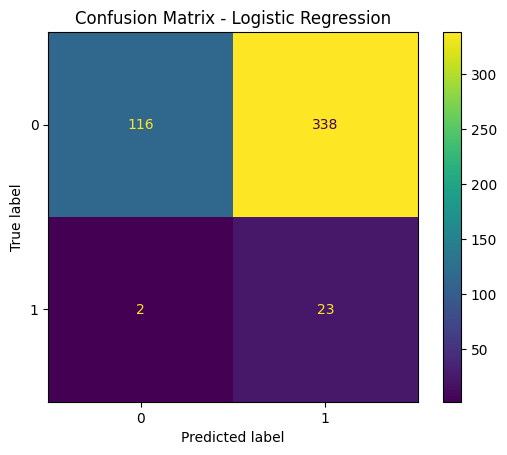


MODEL: Random Forest


Training completed.
Threshold : 0.2
Accuracy  : 0.6472
Precision : 0.0325
Recall    : 0.2000
F1 Score  : 0.0559
ROC-AUC   : 0.4878

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78       454
           1       0.03      0.20      0.06        25

    accuracy                           0.65       479
   macro avg       0.49      0.44      0.42       479
weighted avg       0.89      0.65      0.75       479


Confusion Matrix:
[[305 149]
 [ 20   5]]


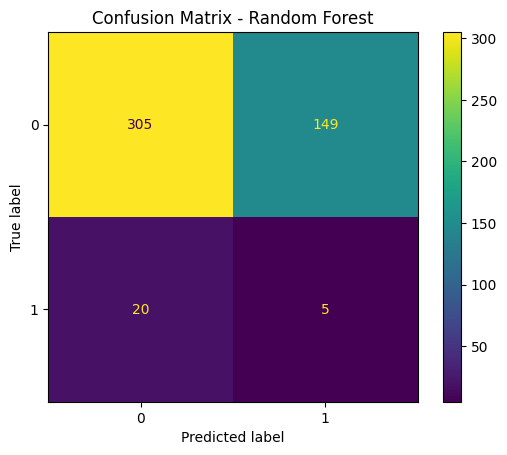


MODEL: XGBoost


Training completed.
Threshold : 0.2
Accuracy  : 0.4196
Precision : 0.0683
Recall    : 0.8000
F1 Score  : 0.1258
ROC-AUC   : 0.6156

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.40      0.57       454
           1       0.07      0.80      0.13        25

    accuracy                           0.42       479
   macro avg       0.52      0.60      0.35       479
weighted avg       0.93      0.42      0.54       479


Confusion Matrix:
[[181 273]
 [  5  20]]


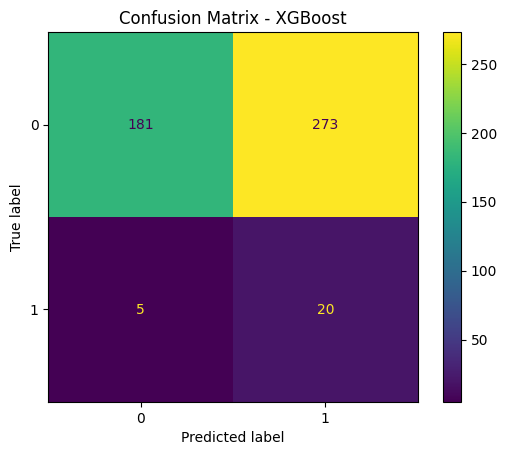


MODEL: CatBoost


Training completed.
Threshold : 0.2
Accuracy  : 0.1921
Precision : 0.0585
Recall    : 0.9600
F1 Score  : 0.1103
ROC-AUC   : 0.5981

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.15      0.26       454
           1       0.06      0.96      0.11        25

    accuracy                           0.19       479
   macro avg       0.52      0.55      0.19       479
weighted avg       0.94      0.19      0.25       479


Confusion Matrix:
[[ 68 386]
 [  1  24]]


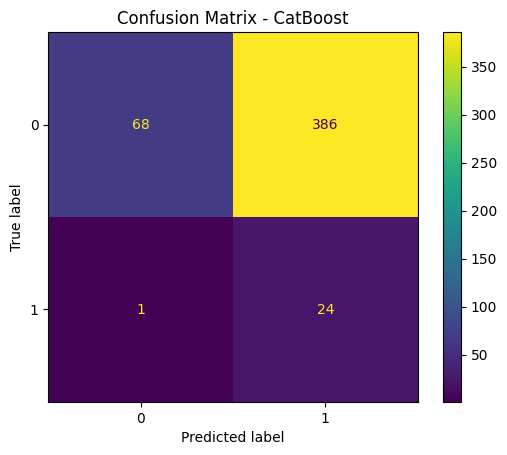

In [11]:
# ==========================
# Train and evaluate
# ==========================

threshold = 0.20
results = []

for model_name, model in models.items():

    print("\n" + "="*70)
    print("MODEL:", model_name)
    print("="*70)

    model.fit(X_train, y_train)
    print("Training completed.")

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"Threshold : {threshold}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

In [12]:
# ==========================
# Final comparison
# ==========================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)

print("\nFINAL MODEL COMPARISON SORTED BY RECALL")
display(results_df)


FINAL MODEL COMPARISON SORTED BY RECALL


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,CatBoost,0.2,0.192067,0.058537,0.96,0.110345,0.598062
0,Logistic Regression,0.2,0.290188,0.063712,0.92,0.119171,0.587665
2,XGBoost,0.2,0.419624,0.068259,0.80,0.125786,0.615595
1,Random Forest,0.2,0.647182,0.032468,0.20,0.055866,0.487753


In [13]:
# ==========================
# Final Comparison Table (Standardized Format)
# ==========================
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].rename(columns={"ROC-AUC": "AUC-ROC"})
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Format as percentage for display
display_df = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, (int, float)) else x)

print("🏆 ASTHMA FINAL MODEL COMPARISON")
display(display_df)



🏆 ASTHMA FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Random Forest,64.72%,3.25%,20.00%,5.59%,48.78%
1,XGBoost,41.96%,6.83%,80.00%,12.58%,61.56%
2,Logistic Regression,29.02%,6.37%,92.00%,11.92%,58.77%
3,CatBoost,19.21%,5.85%,96.00%,11.03%,59.81%


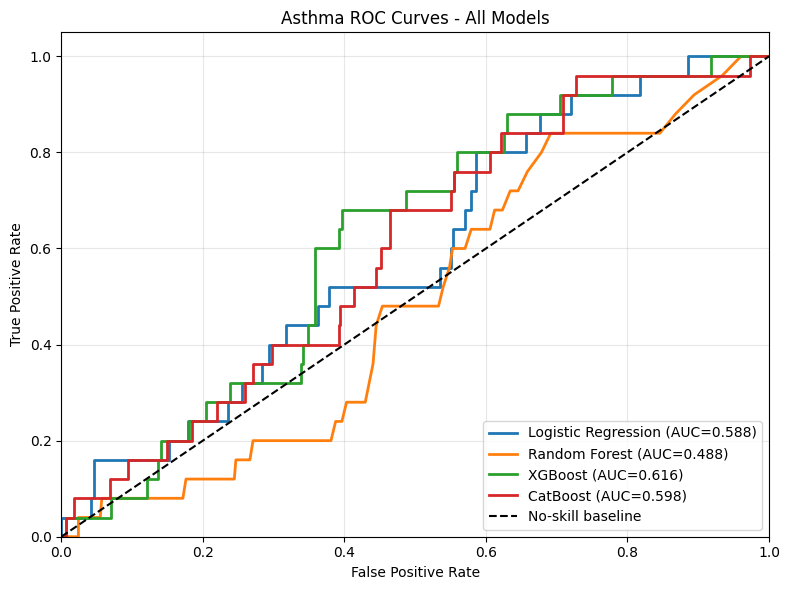

,Model,AUC-ROC
0,XGBoost,0.6156
1,CatBoost,0.5981
2,Logistic Regression,0.5877
3,Random Forest,0.4878


In [14]:
# ==========================
# ASTHMA: ROC-AUC Comparison for All Models
# ==========================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

asthma_roc_rows = []
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    # All Asthma models are pipelines, so use the original X_test directly
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    model_auc = roc_auc_score(y_test, y_prob)

    asthma_roc_rows.append({
        "Model": model_name,
        "AUC-ROC": model_auc
    })

    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={model_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="No-skill baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Asthma ROC Curves - All Models")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

asthma_auc_df = pd.DataFrame(asthma_roc_rows).sort_values(
    by="AUC-ROC", ascending=False
).reset_index(drop=True)

display(asthma_auc_df.style.format({"AUC-ROC": "{:.4f}"}))


In [15]:
# ==========================
# Save Results
# ==========================

results_df.to_csv("Asthma_Model_Comparison.csv", index=False)

print("\nResults saved as: Asthma_Model_Comparison.csv")


Results saved as: Asthma_Model_Comparison.csv


---
# SECTION 2 — IPF
All cells from the original **IPF** notebook are included below.


In [16]:
# ==============================
# STEP 1: Upload Dataset
# ==============================
from google.colab import files
uploaded = files.upload()

In [17]:
# ==============================
# STEP 2: Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import joblib

In [18]:
# ==============================
# STEP 3: Load Dataset
# ==============================
df = pd.read_csv("IPF_Validation_Dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (600, 30)


,PatientID,Age,Sex,BMI,SmokingStatus,PackYears,FamilyHistory_ILD,OccupationalExposure,MUC5B_Variant,GERD,...,SpO2_Rest_Percent,HRCT_Pattern,PulmonaryHypertension,Emphysema_CPFE,CardiovascularDisease,KL6_U_per_mL,SPD_ng_per_mL,GAP_Stage,IPF_Severity,IPF_Diagnosis
0,VAL100262,65,Male,34.4,Ex-smoker,36.2,No,Metal dust,Absent,No,...,92,UIP Probable,Yes,Yes,No,574.0,29.8,I,Mild,Yes
1,VAL100133,69,Male,30.4,Never smoked,0.0,Yes,Wood dust,Present,No,...,96,Alternative Diagnosis,Yes,No,No,1429.0,47.0,Not Applicable,Not Applicable,No
2,VAL100576,63,Male,19.0,Ex-smoker,42.3,Yes,Metal dust,Not tested,Yes,...,91,Indeterminate for UIP,Yes,No,No,333.0,37.7,Not Applicable,Not Applicable,No
3,VAL100455,80,Male,29.0,Ex-smoker,5.0,No,NaN,Not tested,No,...,94,UIP Typical,No,No,No,734.0,35.7,III,Severe,Yes
4,VAL100338,55,Male,32.7,Ex-smoker,28.3,No,NaN,Not tested,No,...,94,UIP Probable,No,No,No,1212.0,65.7,I,Mild,Yes


In [19]:
# ==============================
# STEP 4: Basic Dataset Check
# ==============================
print(df.info())
print("\nNull Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               600 non-null    object 
 1   Age                     600 non-null    int64  
 2   Sex                     600 non-null    object 
 3   BMI                     600 non-null    float64
 4   SmokingStatus           600 non-null    object 
 5   PackYears               600 non-null    float64
 6   FamilyHistory_ILD       600 non-null    object 
 7   OccupationalExposure    219 non-null    object 
 8   MUC5B_Variant           600 non-null    object 
 9   GERD                    600 non-null    object 
 10  mMRC_Dyspnea_Scale      600 non-null    int64  
 11  ChronicCough            600 non-null    object 
 12  VelcroCrackles          600 non-null    object 
 13  DigitalClubbing         600 non-null    object 
 14  FVC_mL                  600 non-null    in

In [20]:
# Keep only diagnosed IPF rows
df = df[df["IPF_Severity"].isin(["Mild", "Moderate", "Severe"])].copy()
# Rename columns to match model expectations
df["FVC"] = df["FVC_mL"]
df["Percent"] = df["FVC_PercentPredicted"]
# Keep only selected 5 features and the severity target
df = df[["FVC", "Percent", "Age", "Sex", "SmokingStatus", "IPF_Severity"]]
df.head()


,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,3276,78.8,65,Male,Ex-smoker,Mild
3,2534,69.7,80,Male,Ex-smoker,Severe
4,2947,71.1,55,Male,Ex-smoker,Mild
5,3727,100.2,62,Female,Never smoked,Mild
6,4603,106.3,64,Male,Ex-smoker,Mild


In [21]:
# ==============================
# STEP 6: Encode Categorical Columns
# ==============================
label_encoders = {}

categorical_cols = ["Sex", "SmokingStatus", "IPF_Severity"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Encoding Done")
df.head()

Encoding Done


,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,3276,78.8,65,1,1,0
3,2534,69.7,80,1,1,2
4,2947,71.1,55,1,1,0
5,3727,100.2,62,0,2,0
6,4603,106.3,64,1,1,0


In [22]:
# ==============================
# STEP 7: Feature and Target Selection
# ==============================
X = df.drop(columns=["IPF_Severity"])
y = df["IPF_Severity"]

print("Features:", X.columns.tolist())
print("Target classes:", label_encoders["IPF_Severity"].classes_)

Features: ['FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']
Target classes: ['Mild' 'Moderate' 'Severe']


In [23]:
# ==============================
# STEP 8: Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (235, 5)
Testing Shape: (59, 5)


In [24]:
# ==============================
# STEP 9: Feature Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
!pip install -q catboost


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="mlogloss"
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=5,
        random_seed=42,
        verbose=0
    )
}

results = {}
ipf_predictions = {} # Store probabilities for ROC plotting

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC-ROC": roc_auc
    }
    ipf_predictions[name] = {"y_prob": y_prob}

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("AUC-ROC:", roc_auc)
    print(classification_report(y_test, y_pred, zero_division=0))



Training Logistic Regression...
Accuracy: 0.7288135593220338
Precision: 0.7431504768847579
Recall: 0.7288135593220338
F1 Score: 0.7254529514903565
AUC-ROC: 0.8439769975786925
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        29
           1       0.68      0.78      0.72        27
           2       1.00      0.33      0.50         3

    accuracy                           0.73        59
   macro avg       0.82      0.61      0.66        59
weighted avg       0.74      0.73      0.73        59


Training Random Forest...


Accuracy: 0.6779661016949152
Precision: 0.6721280602636535
Recall: 0.6779661016949152
F1 Score: 0.673728813559322
AUC-ROC: 0.8241676755447943
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        29
           1       0.63      0.70      0.67        27
           2       0.00      0.00      0.00         3

    accuracy                           0.68        59
   macro avg       0.47      0.48      0.47        59
weighted avg       0.67      0.68      0.67        59


Training XGBoost...


Accuracy: 0.6440677966101694
Precision: 0.6526727509778357
Recall: 0.6440677966101694
F1 Score: 0.6465006893196009
AUC-ROC: 0.7897296206618241
              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.60      0.67      0.63        27
           2       0.00      0.00      0.00         3

    accuracy                           0.64        59
   macro avg       0.46      0.45      0.45        59
weighted avg       0.65      0.64      0.65        59


Training CatBoost...


Accuracy: 0.7796610169491526
Precision: 0.7423728813559322
Recall: 0.7796610169491526
F1 Score: 0.760035682426405
AUC-ROC: 0.8419491525423728
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.73      0.81      0.77        27
           2       0.00      0.00      0.00         3

    accuracy                           0.78        59
   macro avg       0.52      0.55      0.53        59
weighted avg       0.74      0.78      0.76        59



In [27]:
# ==============================
# STEP 11: Compare Model Accuracy
# ==============================
results_df = pd.DataFrame(results).T # Transpose the results dictionary
results_df.index.name = "Model" # Set the index name to 'Model'

results_df = results_df.sort_values(by="Accuracy", ascending=False)
display(results_df)


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
CatBoost,0.779661,0.742373,0.779661,0.760036,0.841949
Logistic Regression,0.728814,0.743150,0.728814,0.725453,0.843977
Random Forest,0.677966,0.672128,0.677966,0.673729,0.824168
XGBoost,0.644068,0.652673,0.644068,0.646501,0.789730


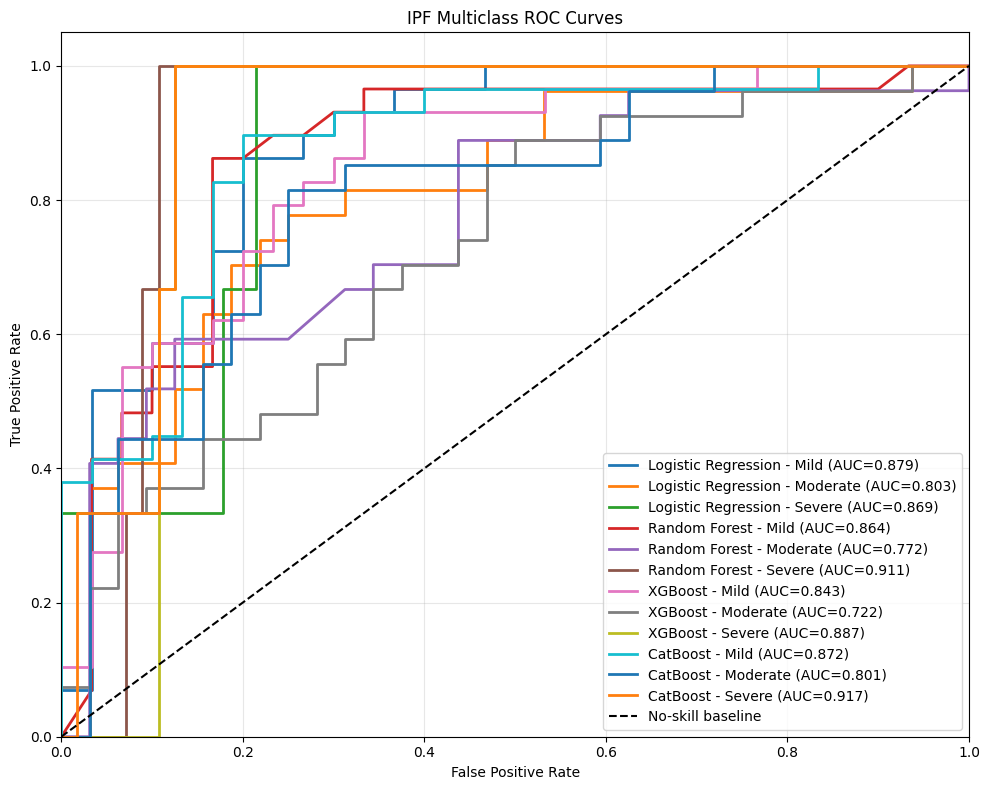

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --- Multiclass ROC Curves (One-vs-Rest) for IPF Models ---

classes = np.sort(y.unique())
class_names = label_encoders["IPF_Severity"].classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

for model_name, pred_data in ipf_predictions.items():
    y_prob = pred_data["y_prob"]

    for class_index, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_index], y_prob[:, class_index])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2,
                 label=f"{model_name} - {class_name} (AUC={class_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="No-skill baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("IPF Multiclass ROC Curves")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()


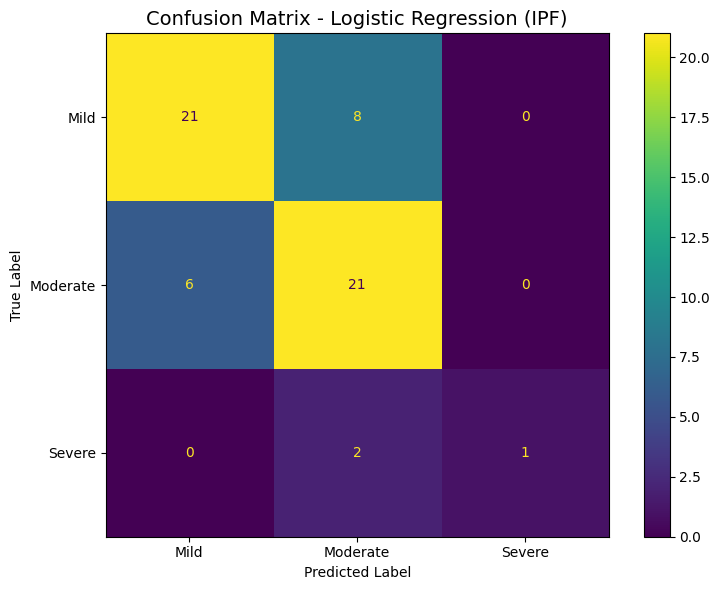

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for Logistic Regression IPF model (improved Severe recall)
logistic_ipf_y_prob = ipf_predictions['Logistic Regression']['y_prob']
logistic_ipf_y_pred = np.argmax(logistic_ipf_y_prob, axis=1)

# Get class names from label_encoders for display
class_names = label_encoders['IPF_Severity'].classes_

# Generate confusion matrix
cm = confusion_matrix(y_test, logistic_ipf_y_pred)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(ax=ax, cmap='viridis')
ax.set_title('Confusion Matrix - Logistic Regression (IPF)', fontsize=14)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

---
# SECTION 3 — PNEUMONIA
All cells from the original **PNEUMONIA** notebook are included below.


In [30]:
from google.colab import files
uploaded = files.upload()

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [32]:
df = pd.read_csv("pneumonia_dataset.csv")

print("Dataset Shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Dataset Shape: (710, 16)


,PatientID,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Xray,WBC_count,Sputum_color,Temperature,Diagnosis
0,PNEU4091,M,3,Bloody,High,Mild,Mild,NaN,No,92,Yes,-,-,-,39.7,Yes
1,PNEU6231,M,3,Dry,NaN,NaN,NaN,Mild,-,-,Yes,-,-,Clear,37.0,No
2,PNEU6486,M,3,Dry,NaN,NaN,NaN,Mild,No,99,No,-,-,-,38.0,No
3,PNEU7601,F,3,NaN,Low,Severe,NaN,Moderate,No,99,Yes,-,-,Clear,40.9,Yes
4,PNEU8471,F,3,NaN,High,Moderate,Severe,Mild,-,91,No,-,-,Green,38.1,Yes


['PatientID', 'Gender', 'Age', 'Cough', 'Fever', 'Shortness_of_breath', 'Chest_pain', 'Fatigue', 'Confusion', 'Oxygen_saturation', 'Crackles', 'Xray', 'WBC_count', 'Sputum_color', 'Temperature', 'Diagnosis']


In [33]:
required_columns = [
    "Fever",
    "Cough",
    "Chest_pain",
    "WBC_count",
    "Oxygen_saturation",
    "Shortness_of_breath",
    "Diagnosis"
]

df = df[required_columns]

display(df.head())
print(df.isnull().sum())

,Fever,Cough,Chest_pain,WBC_count,Oxygen_saturation,Shortness_of_breath,Diagnosis
0,High,Bloody,Mild,-,92,Mild,Yes
1,NaN,Dry,NaN,-,-,NaN,No
2,NaN,Dry,NaN,-,99,NaN,No
3,Low,NaN,NaN,-,99,Severe,Yes
4,High,NaN,Severe,-,91,Moderate,Yes


Fever                  310
Cough                  312
Chest_pain             343
WBC_count                0
Oxygen_saturation        0
Shortness_of_breath    317
Diagnosis                0
dtype: int64


In [34]:
# ==============================
# Cell 5: Clean missing and invalid values
# ==============================

df = df.replace("-", np.nan)

print("Null values after replacing '-':")
print(df.isnull().sum())

print("\nDataset shape before dropping Diagnosis nulls:", df.shape)

# Diagnosis must not be missing
df = df.dropna(subset=["Diagnosis"])

print("Dataset shape after cleaning:", df.shape)

Null values after replacing '-':
Fever                  310
Cough                  312
Chest_pain             343
WBC_count              700
Oxygen_saturation       60
Shortness_of_breath    317
Diagnosis                0
dtype: int64

Dataset shape before dropping Diagnosis nulls: (710, 7)
Dataset shape after cleaning: (710, 7)


In [35]:
# ==============================
# Cell 6: Rename Columns
# ==============================

df = df.rename(columns={
    "Chest_pain": "ChestPain",
    "WBC_count": "WBCCount",
    "Oxygen_saturation": "SpO2",
    "Shortness_of_breath": "RespiratorySymptom"
})

display(df.head())

,Fever,Cough,ChestPain,WBCCount,SpO2,RespiratorySymptom,Diagnosis
0,High,Bloody,Mild,NaN,92,Mild,Yes
1,NaN,Dry,NaN,NaN,NaN,NaN,No
2,NaN,Dry,NaN,NaN,99,NaN,No
3,Low,NaN,NaN,NaN,99,Severe,Yes
4,High,NaN,Severe,NaN,91,Moderate,Yes


In [36]:
# ==============================
# Cell 7: Encode Categorical Columns
# ==============================

encoding_maps = {

    "Fever": {
        "Low":1,
        "Moderate":2,
        "High":3
    },

    "Cough":{
        "Dry":1,
        "Wet":2,
        "Bloody":3
    },

    "ChestPain":{
        "Mild":1,
        "Moderate":2,
        "Severe":3
    },

    "RespiratorySymptom":{
        "Mild":1,
        "Moderate":2,
        "Severe":3
    },

    "Diagnosis":{
        "No":0,
        "Yes":1
    }

}

for column,mapping in encoding_maps.items():
    df[column]=df[column].map(mapping)

df["WBCCount"]=pd.to_numeric(df["WBCCount"],errors="coerce")
df["SpO2"]=pd.to_numeric(df["SpO2"],errors="coerce")

display(df.head())

print(df.isnull().sum())

,Fever,Cough,ChestPain,WBCCount,SpO2,RespiratorySymptom,Diagnosis
0,3.0,3.0,1.0,NaN,92.0,1.0,1
1,NaN,1.0,NaN,NaN,NaN,NaN,0
2,NaN,1.0,NaN,NaN,99.0,NaN,0
3,1.0,NaN,NaN,NaN,99.0,3.0,1
4,3.0,NaN,3.0,NaN,91.0,2.0,1


Fever                 310
Cough                 312
ChestPain             343
WBCCount              700
SpO2                   60
RespiratorySymptom    317
Diagnosis               0
dtype: int64


In [37]:
# ==============================
# Cell 8: Feature Selection
# ==============================

features = [
    "Fever",
    "Cough",
    "ChestPain",
    "WBCCount",
    "SpO2",
    "RespiratorySymptom"
]

target = "Diagnosis"

X = df[features]
y = df[target]

print("Features:")
print(features)

print("\nTarget Distribution:")
print(y.value_counts())

Features:
['Fever', 'Cough', 'ChestPain', 'WBCCount', 'SpO2', 'RespiratorySymptom']

Target Distribution:
Diagnosis
1    408
0    302
Name: count, dtype: int64


In [38]:
# ==============================
# Cell 9: Handle Missing Values
# ==============================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=features
)

print("Remaining Missing Values")
print(X.isnull().sum())

Remaining Missing Values
Fever                 0
Cough                 0
ChestPain             0
WBCCount              0
SpO2                  0
RespiratorySymptom    0
dtype: int64


In [39]:
# ==============================
# Cell 10: Train Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:",X_train.shape)
print("Testing Samples :",X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts())

Training Samples: (568, 6)
Testing Samples : (142, 6)

Training Class Distribution
Diagnosis
1    326
0    242
Name: count, dtype: int64


In [40]:
# ==============================
# Cell 11: Scaling
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed.")

Scaling Completed.


In [41]:
!pip install -q catboost lightgbm imbalanced-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [43]:
# ==============================
# Apply SMOTE for Class Balancing
# ==============================

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()

X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
Diagnosis
1    326
0    242
Name: count, dtype: int64

After SMOTE:
Diagnosis
1    326
0    326
Name: count, dtype: int64


In [44]:
# ==============================
# Define Improved Models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=4,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        verbose=0,
        random_state=42
    )
}

In [45]:
# ==============================
# Train Multiple Models with AUC-ROC
# ==============================

from sklearn.metrics import roc_auc_score

results = []
pneumonia_predictions = {}
threshold = 0.25

for name, model in models.items():
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")

    if name == "Logistic Regression":
        model.fit(X_train_balanced_scaled, y_train_balanced)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        model.fit(X_train_balanced, y_train_balanced)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC-ROC": roc_auc
    })
    pneumonia_predictions[name] = {"y_pred": y_pred, "y_prob": y_prob}

    print(f"Threshold: {threshold}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC-ROC  : {roc_auc:.4f}\n")
    print(classification_report(y_test, y_pred, zero_division=0))


Training Logistic Regression
Threshold: 0.25
Accuracy : 0.6549
Precision: 0.6578
Recall   : 0.6549
F1 Score : 0.6292
AUC-ROC  : 0.7647

              precision    recall  f1-score   support

           0       0.67      0.37      0.47        60
           1       0.65      0.87      0.74        82

    accuracy                           0.65       142
   macro avg       0.66      0.62      0.61       142
weighted avg       0.66      0.65      0.63       142


Training Random Forest


Threshold: 0.25
Accuracy : 0.7606
Precision: 0.7606
Recall   : 0.7606
F1 Score : 0.7606
AUC-ROC  : 0.8580

              precision    recall  f1-score   support

           0       0.72      0.72      0.72        60
           1       0.79      0.79      0.79        82

    accuracy                           0.76       142
   macro avg       0.75      0.75      0.75       142
weighted avg       0.76      0.76      0.76       142


Training XGBoost


Threshold: 0.25
Accuracy : 0.7254
Precision: 0.7232
Recall   : 0.7254
F1 Score : 0.7225
AUC-ROC  : 0.8590

              precision    recall  f1-score   support

           0       0.70      0.62      0.65        60
           1       0.74      0.80      0.77        82

    accuracy                           0.73       142
   macro avg       0.72      0.71      0.71       142
weighted avg       0.72      0.73      0.72       142


Training CatBoost


Threshold: 0.25
Accuracy : 0.7394
Precision: 0.7389
Recall   : 0.7394
F1 Score : 0.7345
AUC-ROC  : 0.8641

              precision    recall  f1-score   support

           0       0.73      0.60      0.66        60
           1       0.74      0.84      0.79        82

    accuracy                           0.74       142
   macro avg       0.74      0.72      0.72       142
weighted avg       0.74      0.74      0.73       142



In [46]:
# ==============================
# REPORT 1: Performance Comparison Table
# ==============================

import pandas as pd
from IPython.display import HTML, display

results_df = pd.DataFrame(results)

# Select Best Model
best_row = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

performance_table = results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
].copy()

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]

performance_table[metric_cols] = (
    performance_table[metric_cols] * 100
).round(2)

performance_table = (
    performance_table
    .sort_values(by="Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(
    HTML(
        performance_table.to_html(
            index=False,
            border=1,
            justify="center"
        )
    )
)

Best Model: Random Forest


Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Random Forest,76.06,76.06,76.06,76.06,85.80
CatBoost,73.94,73.89,73.94,73.45,86.41
XGBoost,72.54,72.32,72.54,72.25,85.90
Logistic Regression,65.49,65.78,65.49,62.92,76.47


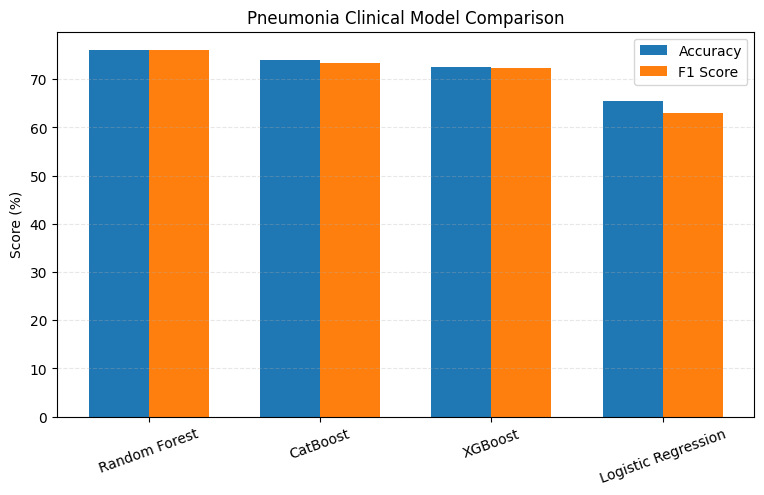

In [47]:
# ==============================
# REPORT 2: Accuracy vs F1 Score
# ==============================

import matplotlib.pyplot as plt
import numpy as np

plot_df = performance_table.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(x-width/2,
        plot_df["Accuracy"],
        width,
        label="Accuracy")

plt.bar(x+width/2,
        plot_df["F1 Score"],
        width,
        label="F1 Score")

plt.xticks(x, plot_df["Model"], rotation=20)

plt.ylabel("Score (%)")
plt.title("Pneumonia Clinical Model Comparison")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

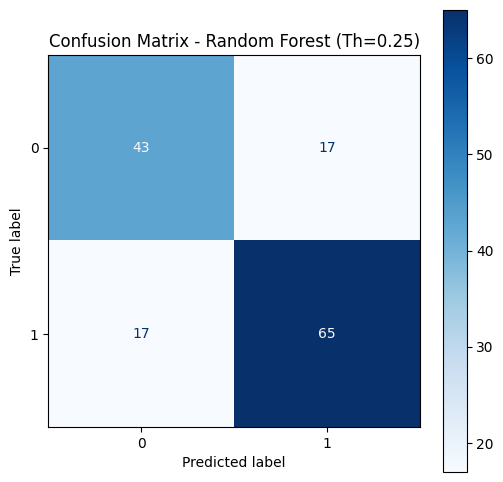

In [48]:
# ==============================
# REPORT 3: Confusion Matrix
# ==============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

threshold = 0.25
if best_model_name == "Logistic Regression":
    y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_prob_best = best_model.predict_proba(X_test)[:, 1]

y_pred_best = (y_prob_best >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(f"Confusion Matrix - {best_model_name} (Th={threshold})")
plt.grid(False)
plt.show()

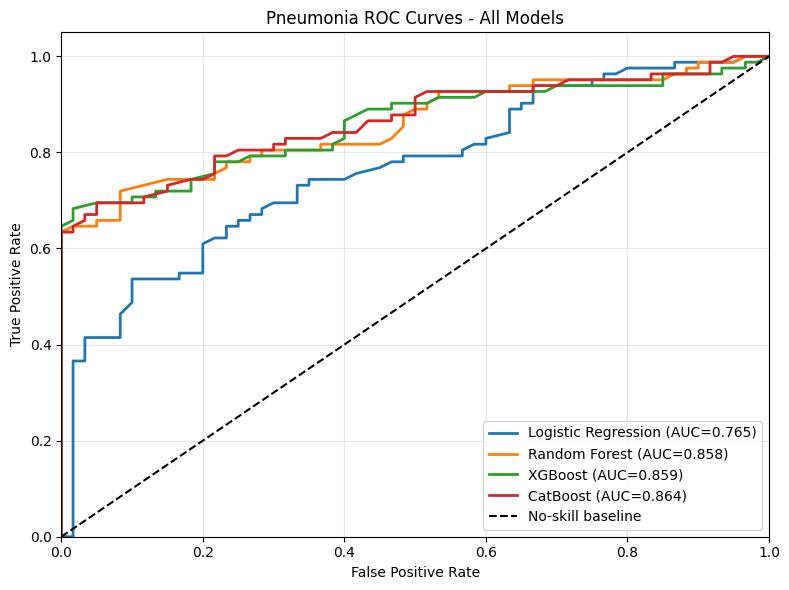

,Model,AUC-ROC
0,CatBoost,0.8641
1,XGBoost,0.8590
2,Random Forest,0.8580
3,Logistic Regression,0.7647


In [49]:
# ==============================
# REPORT 4: ROC Curves and AUC for All Pneumonia Models
# ==============================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for model_name, pred_data in pneumonia_predictions.items():
    y_prob = pred_data["y_prob"]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    model_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{model_name} (AUC={model_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="No-skill baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pneumonia ROC Curves - All Models")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

pneumonia_auc_df = results_df[["Model", "AUC-ROC"]].sort_values(
    by="AUC-ROC", ascending=False
).reset_index(drop=True)
display(pneumonia_auc_df.style.format({"AUC-ROC": "{:.4f}"}))

---
# SECTION 4 — COPD
All cells from the original **COPD** notebook are included below.


In [50]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm openpyxl -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
# Cell 2: Upload the Excel file directly from your computer
from google.colab import files
uploaded = files.upload()  # A file picker will appear — select Dataset_PowerBI__1_.xlsx
print("✅ Uploaded:", list(uploaded.keys()))

✅ Uploaded: ['asthma_disease_data.csv', 'IPF_Validation_Dataset.csv', 'pneumonia_dataset.csv', 'COPD_Dataset.xlsx']


In [52]:
# Cell 3: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [53]:
# Cell 4: Load Sheet1 and Sheet2 and combine them
# Sheet1 has 'Patient ID' column, Sheet2 does not — we drop it before merging

df1 = pd.read_excel('COPD_Dataset.xlsx', sheet_name='Sheet1')
df2 = pd.read_excel('COPD_Dataset.xlsx', sheet_name='Sheet2')

# Drop Patient ID if present
if 'Patient ID' in df1.columns:
    df1 = df1.drop(columns=['Patient ID'])

df = pd.concat([df1, df2], ignore_index=True)
print(f"✅ Sheet1: {df1.shape} | Sheet2: {df2.shape} | Combined: {df.shape}")
print("\nAll columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i:02d}] {c}")

✅ Sheet1: (1166, 58) | Sheet2: (1068, 58) | Combined: (2234, 58)

All columns:
  [00] Gender
  [01] Age
  [02] Heigt(cm)
  [03] Height(in)
  [04] weight kg
  [05] weight (lb)
  [06] BMI
  [07] Smoker
  [08] Comorbidity1
  [09] Comorbidity 2
  [10] Comorbidity 3
  [11] COPD Medication
  [12] Baseline Dyspnea (mMRC)
  [13] COPD Gold Stage
  [14] Baseline heartrate
  [15] H Reserve
  [16] Heartrate Max
  [17] HR During light exercise
  [18] HR During moderate exercise
  [19] HR During vigorous exercise
  [20] Baseline temperature
  [21] Baseline temperature C
  [22] T During light exercise
  [23] T During moderate exercise
  [24] T During vigorous exercise
  [25] Baseline SpO2
  [26] SpO2 During light exercise
  [27] SpO2 During moderate exercise
  [28] SpO2 During vigorous exercise
  [29] Baseline  PaO2
  [30]  PaO2 During light exercise
  [31] PaO2During moderate exercise
  [32] PaO2 During vigorous exercise
  [33] Baseline PaCO2
  [34] PaCO2 During light exercise
  [35] PaCO2 During mo

In [54]:
# Cell 5: Select features matching the COPD clinical parameters from Image 2
# COPD features: Age, Gender, Smoking Status, BMI, FVC(L), FEV1(L),
#                FEV1/FVC Ratio, SpO2(%), Respiratory Rate, Cough(Y/N), Dyspnea Score

# From the dataset:
# - Age                   → 'Age'
# - Gender                → 'Gender'
# - Smoking Status        → 'Smoker'
# - BMI                   → 'BMI'
# - FEV1 (L)              → 'Baseline FEV1'  (Current FEV1 has messy string format)
# - SpO2 (%)              → 'Baseline SpO2'
# - Respiratory Rate      → 'Baseline Respiration Rate'
# - Dyspnea Score         → 'Baseline Dyspnea (mMRC)'  (mMRC1–mMRC5)
# - Cough (Y/N)           → NOT directly in dataset; we use comorbidities as proxy
# - FVC (L)               → NOT present; we'll approximate FEV1/FVC from GOLD stage
# - TARGET                → 'COPD Gold Stage' (Stage 1 / 2 / 3 / 4)

FEATURES = [
    'Age',
    'Gender',
    'Smoker',
    'BMI',
    'Baseline FEV1',         # FEV1 (L)
    'Baseline SpO2',         # SpO2 (%)
    'Baseline Respiration Rate',   # Respiratory Rate
    'Baseline Dyspnea (mMRC)',     # Dyspnea Score (mMRC scale)
    'Baseline heartrate',          # Additional clinical signal
]
TARGET = 'COPD Gold Stage'

df_model = df[FEATURES + [TARGET]].copy()
print(f"✅ Working DataFrame shape: {df_model.shape}")
print(f"\nTarget distribution:\n{df_model[TARGET].value_counts()}")
df_model.head()

✅ Working DataFrame shape: (2234, 10)

Target distribution:
COPD Gold Stage
Stage 2    1356
Stage 3     309
Stage 1     298
Stage 4     271
Name: count, dtype: int64


,Age,Gender,Smoker,BMI,Baseline FEV1,Baseline SpO2,Baseline Respiration Rate,Baseline Dyspnea (mMRC),Baseline heartrate,COPD Gold Stage
0,88,Male,No,23.746689,0.729397,95.173109,42.055429,mMRC2,96.0,Stage 3
1,60,Female,No,28.416852,1.358489,96.362210,7.378096,mMRC4,67.0,Stage 1
2,55,Male,No,36.411591,1.588316,91.269500,20.863206,mMRC4,98.0,Stage 3
3,55,Female,No,28.117001,0.549915,94.846078,27.645493,mMRC2,84.0,Stage 4
4,65,Male,No,26.343269,1.337281,91.781191,12.150289,mMRC5,93.0,Stage 4


In [55]:
# Cell 6: Clean and encode all features

df_proc = df_model.copy()

# --- Dyspnea Score: extract number from 'mMRC2' → 2 ---
df_proc['Baseline Dyspnea (mMRC)'] = (
    df_proc['Baseline Dyspnea (mMRC)']
    .astype(str).str.extract(r'(\d+)').astype(float)
)

# --- Encode Gender: Male=1, Female=0 ---
df_proc['Gender'] = df_proc['Gender'].map({'Male': 1, 'Female': 0})

# --- Encode Smoker: Yes=1, No=0 ---
df_proc['Smoker'] = df_proc['Smoker'].map({'Yes': 1, 'No': 0})

# --- Encode Target: Stage 1→0, Stage 2→1, Stage 3→2, Stage 4→3 ---
stage_map = {'Stage 1': 0, 'Stage 2': 1, 'Stage 3': 2, 'Stage 4': 3}
df_proc['target'] = df_proc[TARGET].map(stage_map)
df_proc = df_proc.drop(columns=[TARGET])

# --- Impute missing values with median ---
for col in df_proc.columns:
    if df_proc[col].isnull().sum() > 0:
        median_val = df_proc[col].median()
        df_proc[col].fillna(median_val, inplace=True)
        print(f"  Imputed '{col}' with median={median_val:.3f}")

print(f"\n✅ Processed shape: {df_proc.shape}")
print(f"Missing values remaining: {df_proc.isnull().sum().sum()}")
print(f"\nTarget class distribution:\n{df_proc['target'].value_counts().sort_index()}")
df_proc.head()


✅ Processed shape: (2234, 10)
Missing values remaining: 0

Target class distribution:
target
0     298
1    1356
2     309
3     271
Name: count, dtype: int64


,Age,Gender,Smoker,BMI,Baseline FEV1,Baseline SpO2,Baseline Respiration Rate,Baseline Dyspnea (mMRC),Baseline heartrate,target
0,88,1,0,23.746689,0.729397,95.173109,42.055429,2.0,96.0,2
1,60,0,0,28.416852,1.358489,96.362210,7.378096,4.0,67.0,0
2,55,1,0,36.411591,1.588316,91.269500,20.863206,4.0,98.0,2
3,55,0,0,28.117001,0.549915,94.846078,27.645493,2.0,84.0,3
4,65,1,0,26.343269,1.337281,91.781191,12.150289,5.0,93.0,3


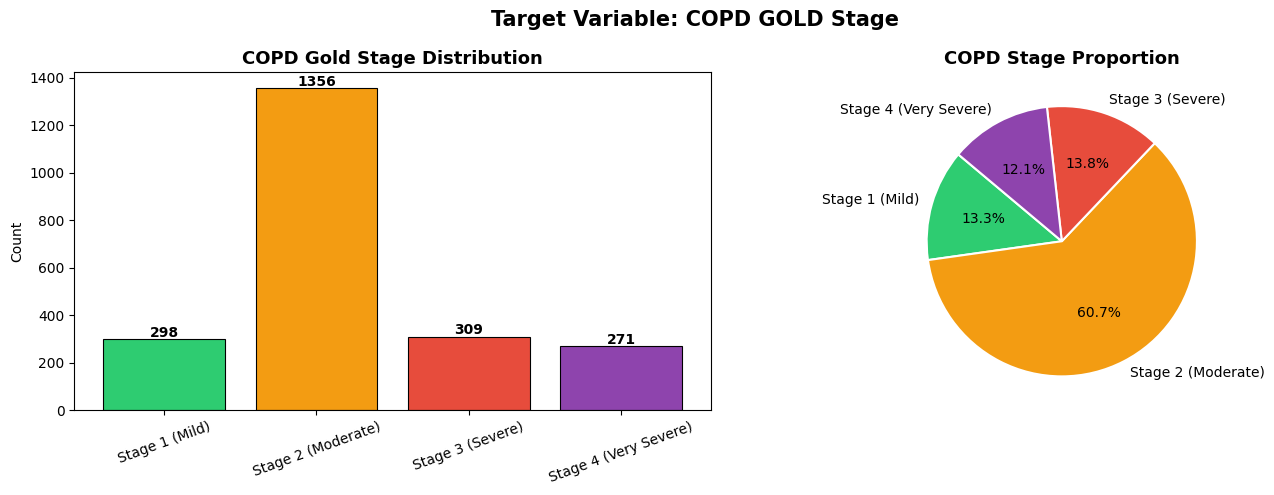

In [56]:
# Cell 7: Visualize class distribution
labels = ['Stage 1 (Mild)', 'Stage 2 (Moderate)', 'Stage 3 (Severe)', 'Stage 4 (Very Severe)']
counts = df_proc['target'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[0].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('COPD Gold Stage Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('COPD Stage Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: COPD GOLD Stage', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('copd_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

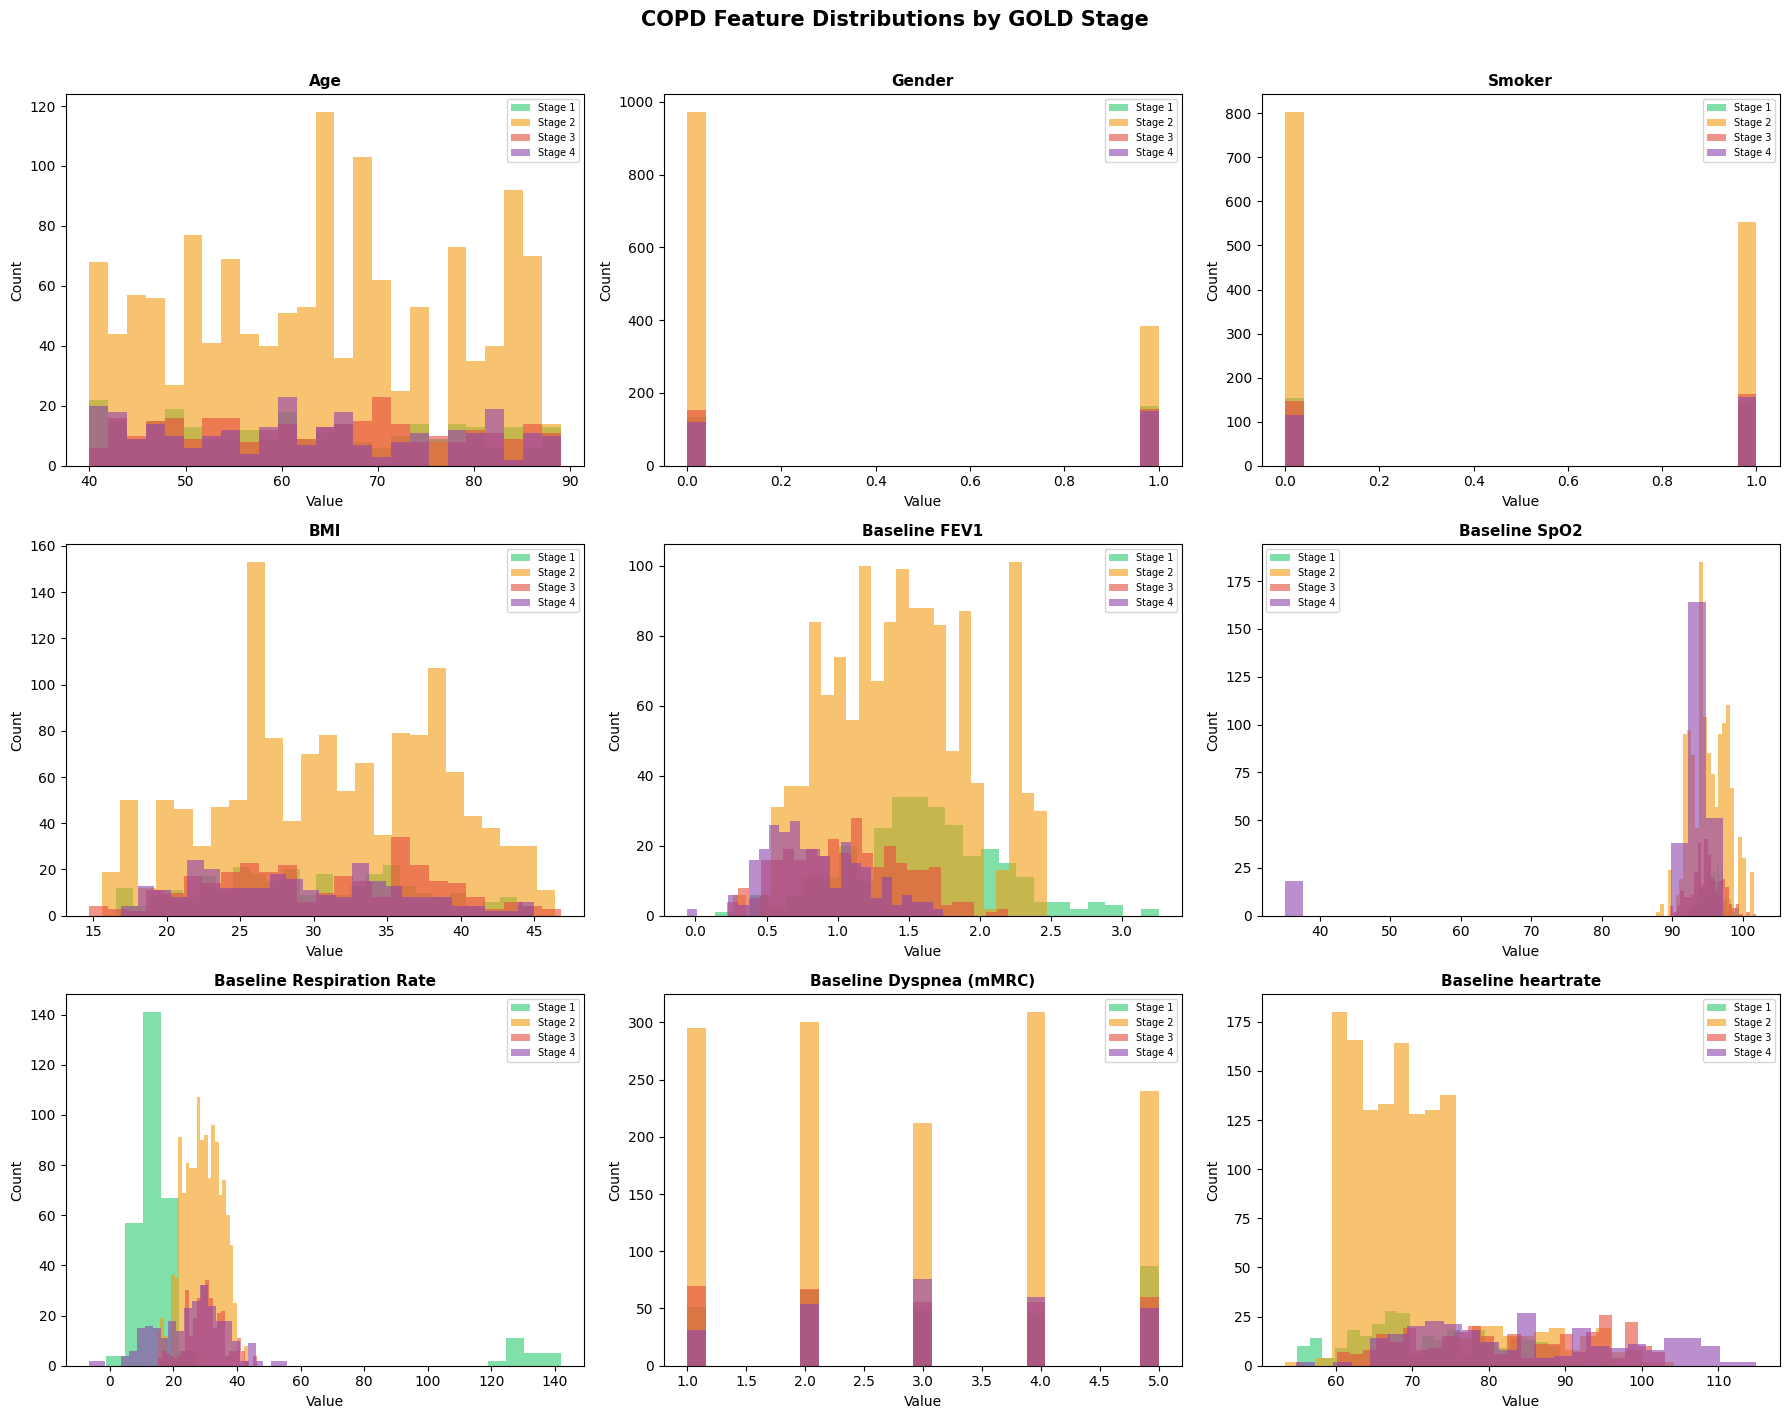

In [57]:
# Cell 8: Feature distributions by COPD stage
feature_cols = [c for c in df_proc.columns if c != 'target']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
palette = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for i, col in enumerate(feature_cols):
    for j, stage in enumerate([0, 1, 2, 3]):
        data = df_proc[df_proc['target'] == stage][col]
        axes[i].hist(data, bins=25, alpha=0.6, color=palette[j],
                     label=stage_labels[j], edgecolor='none')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

plt.suptitle('COPD Feature Distributions by GOLD Stage', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('copd_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# Cell 23: Install CatBoost (not in default Colab)
!pip install catboost -q
from catboost import CatBoostClassifier
print("✅ CatBoost installed and imported!")

✅ CatBoost installed and imported!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
# Cell 24: Define the 4 models specified by trainer
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']

four_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, eval_metric='mlogloss',
                                          use_label_encoder=False, random_state=42),
    'CatBoost':            CatBoostClassifier(iterations=300, random_seed=42,
                                               verbose=0, auto_class_weights='Balanced'),
}

# LR and SVM use scaled data, tree models use raw
SCALED = {'Logistic Regression'}

print("✅ 4 Models ready:")
for name in four_models:
    print(f"   → {name}")

✅ 4 Models ready:
   → Logistic Regression
   → Random Forest
   → XGBoost
   → CatBoost


In [60]:
# ==============================
# Cell 24.5: Perform Stratified Train-Test Split on COPD Dataset
# ==============================
from sklearn.model_selection import train_test_split

X = df_proc.drop(columns=['target'])
y = df_proc['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ COPD Train shape: {X_train.shape} | Test shape: {X_test.shape}")

✅ COPD Train shape: (1787, 9) | Test shape: (447, 9)


In [61]:
# ==============================
# Cell 25: Train all models
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import cross_val_score
import numpy as np

# ------------------------------
# Create scaled data if required
# ------------------------------
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Models that require scaling
SCALED = {"Logistic Regression"}

four_results = {}

print(f"{'Model':<22} {'Accuracy':>10} {'AUC':>12} {'CV Mean':>10} {'CV Std':>8}")
print("=" * 70)

# Number of classes
n_classes = len(np.unique(y_train))

for name, model in four_models.items():

    # Select scaled or unscaled features
    if name in SCALED:
        Xtr = X_train_sc
        Xte = X_test_sc
    else:
        Xtr = X_train.values if hasattr(X_train, "values") else X_train
        Xte = X_test.values if hasattr(X_test, "values") else X_test

    # Train
    model.fit(Xtr, y_train)

    # Predictions
    y_pred = model.predict(Xte)

    # Probabilities (if supported)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(Xte)
    else:
        y_prob = None

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # -------------------------
    # ROC-AUC
    # -------------------------
    if y_prob is not None:
        try:
            if n_classes == 2:
                auc = roc_auc_score(y_test, y_prob[:, 1])
            else:
                auc = roc_auc_score(
                    y_test,
                    y_prob,
                    multi_class="ovr",
                    average="macro"
                )
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # -------------------------
    # Cross Validation
    # -------------------------
    cv_scores = cross_val_score(
        model,
        Xtr,
        y_train,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    four_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "accuracy": acc,
        "auc": auc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "cv_scores": cv_scores
    }

    print(
        f"{name:<22} "
        f"{acc:>10.4f} "
        f"{auc:>12.4f} "
        f"{cv_scores.mean():>10.4f} "
        f"{cv_scores.std():>8.4f}"
    )

print("\n✅ All models trained successfully!")


Model                    Accuracy          AUC    CV Mean   CV Std


Logistic Regression        0.7136       0.8574     0.7174   0.0184


Random Forest              0.9530       0.9952     0.9205   0.0033


XGBoost                    0.9620       0.9947     0.9278   0.0053


CatBoost                   0.9642       0.9921     0.9345   0.0058

✅ All models trained successfully!


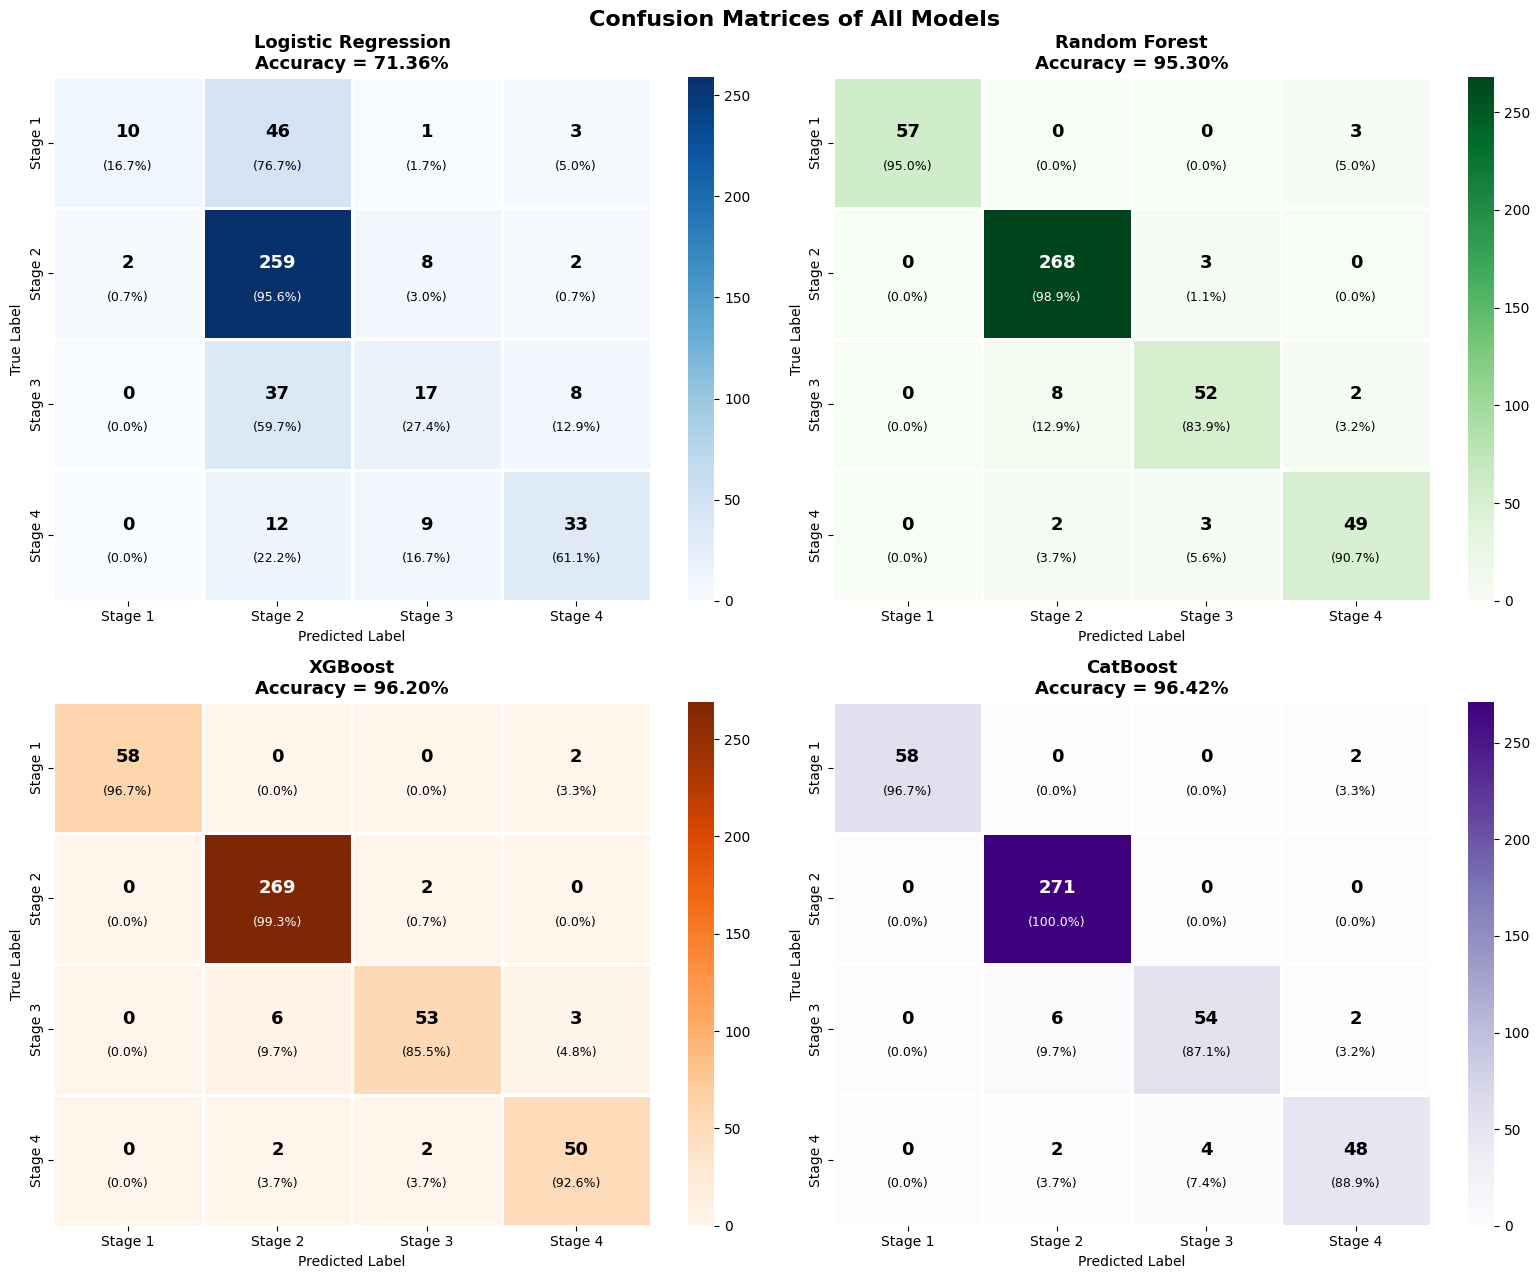

✅ Saved: four_models_confusion_matrices.png


In [62]:
# ==============================
# Cell 26: Confusion Matrices
# Works for Binary & Multiclass
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

model_colors = {
    "Logistic Regression": "Blues",
    "Random Forest": "Greens",
    "XGBoost": "Oranges",
    "CatBoost": "Purples",
}

for i, (name, r) in enumerate(four_results.items()):

    cm = confusion_matrix(y_test, r["y_pred"])

    # Number of classes
    n_classes = cm.shape[0]

    # Automatically generate labels if stage_names doesn't match
    if "stage_names" in globals() and len(stage_names) == n_classes:
        labels = stage_names
    else:
        labels = [str(c) for c in np.unique(y_test)]

    # Percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_pct = np.nan_to_num(cm_pct) * 100

    sns.heatmap(
        cm,
        annot=False,
        cmap=model_colors.get(name, "Blues"),
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.8,
        linecolor="white",
        cbar=True,
        ax=axes[i],
        vmin=0,
        vmax=cm.max()
    )

    # Dynamic annotation
    for row in range(n_classes):
        for col in range(n_classes):

            count = cm[row, col]
            pct = cm_pct[row, col]

            color = "white" if count > cm.max() * 0.6 else "black"

            axes[i].text(
                col + 0.5,
                row + 0.42,
                f"{count}",
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=color,
            )

            axes[i].text(
                col + 0.5,
                row + 0.68,
                f"({pct:.1f}%)",
                ha="center",
                va="center",
                fontsize=9,
                color=color,
            )

    axes[i].set_title(
        f"{name}\nAccuracy = {r['accuracy']*100:.2f}%",
        fontsize=13,
        fontweight="bold",
    )

    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.suptitle("Confusion Matrices of All Models", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.savefig("four_models_confusion_matrices.png", dpi=150)

plt.show()

print("✅ Saved: four_models_confusion_matrices.png")

In [63]:
all_reports = {}

# Determine the classes present
classes = np.unique(y_test)

# Determine appropriate class names
if "stage_names" in globals() and len(stage_names) == len(classes):
    class_names = stage_names
else:
    class_names = [str(c) for c in classes]

for name, r in four_results.items():

    report = classification_report(
        y_test,
        r["y_pred"],
        labels=classes,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).T.round(4)

    all_reports[name] = df_report

    print("\n" + "=" * 70)
    print(f"{name}")
    print("=" * 70)
    print(df_report)


Logistic Regression
              precision  recall  f1-score   support
Stage 1          0.8333  0.1667    0.2778   60.0000
Stage 2          0.7316  0.9557    0.8288  271.0000
Stage 3          0.4857  0.2742    0.3505   62.0000
Stage 4          0.7174  0.6111    0.6600   54.0000
accuracy         0.7136  0.7136    0.7136    0.7136
macro avg        0.6920  0.5019    0.5293  447.0000
weighted avg     0.7095  0.7136    0.6681  447.0000

Random Forest
              precision  recall  f1-score  support
Stage 1          1.0000  0.9500    0.9744   60.000
Stage 2          0.9640  0.9889    0.9763  271.000
Stage 3          0.8966  0.8387    0.8667   62.000
Stage 4          0.9074  0.9074    0.9074   54.000
accuracy         0.9530  0.9530    0.9530    0.953
macro avg        0.9420  0.9213    0.9312  447.000
weighted avg     0.9527  0.9530    0.9525  447.000

XGBoost
              precision  recall  f1-score  support
Stage 1          1.0000  0.9667    0.9831   60.000
Stage 2          0.9711  0.99

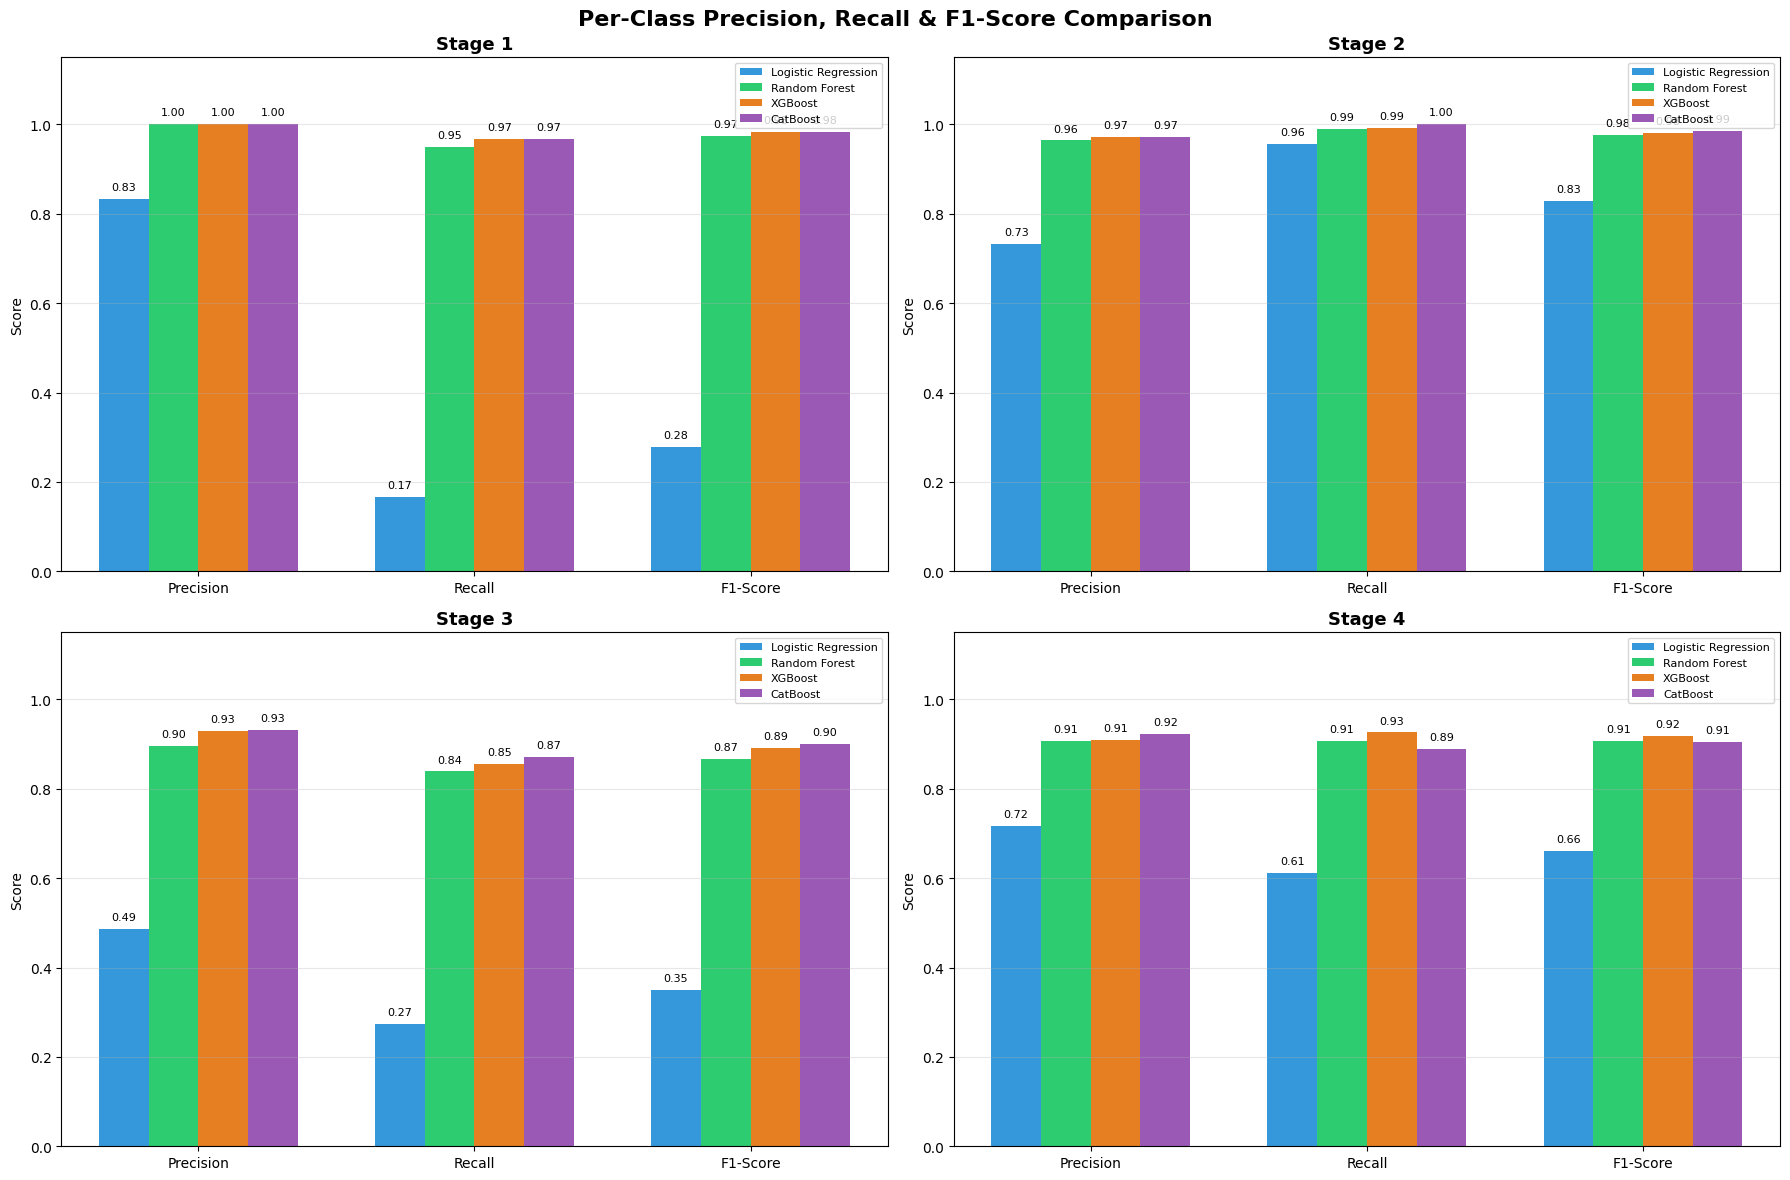

✅ Saved: four_models_performance_by_stage.png


In [64]:
metrics_to_plot = ["precision", "recall", "f1-score"]
metric_labels = ["Precision", "Recall", "F1-Score"]

# Determine classes present
classes = np.unique(y_test)
n_classes = len(classes)

# Determine class names
if "stage_names" in globals() and len(stage_names) == n_classes:
    class_names = stage_names
else:
    class_names = [str(c) for c in classes]

# Colors
model_colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

# Figure layout
cols = 2
rows = int(np.ceil(n_classes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))

# Flatten axes safely
if rows == 1:
    axes = np.array(axes).reshape(-1)
else:
    axes = axes.flatten()

for s_idx, stage in enumerate(class_names):

    ax = axes[s_idx]

    x = np.arange(len(metrics_to_plot))
    width = 0.18

    for m_idx, (name, r) in enumerate(four_results.items()):

        report = classification_report(
            y_test,
            r["y_pred"],
            labels=classes,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )

        values = [report[stage][m] for m in metrics_to_plot]

        bars = ax.bar(
            x + m_idx * width,
            values,
            width,
            color=model_colors[m_idx],
            label=name,
        )

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.02,
                f"{value:.2f}",
                ha="center",
                fontsize=8,
            )

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(metric_labels)

    ax.set_ylim(0, 1.15)

    ax.set_title(stage, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)

    ax.legend(fontsize=8)

# Hide unused subplot(s)
for i in range(n_classes, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Per-Class Precision, Recall & F1-Score Comparison",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

plt.savefig("four_models_performance_by_stage.png", dpi=150)

plt.show()

print("✅ Saved: four_models_performance_by_stage.png")

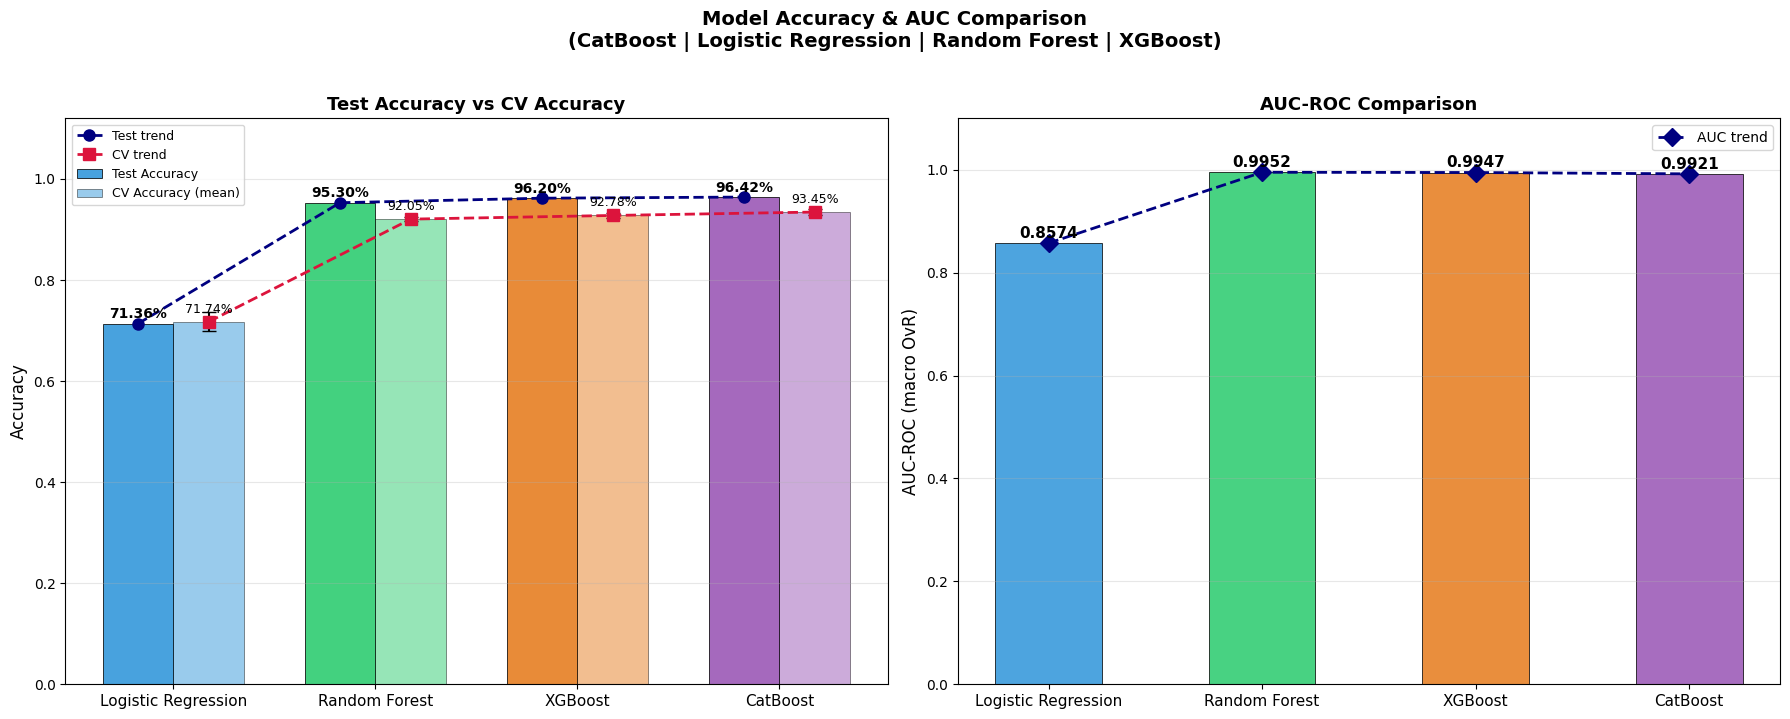

✅ Saved: four_models_accuracy_comparison.png


In [65]:
# Cell 29: Accuracy comparison — grouped bar with CV error bars + trend line
import matplotlib.pyplot as plt
import numpy as np

names      = list(four_results.keys())
accs       = [four_results[n]['accuracy']  for n in names]
cv_means   = [four_results[n]['cv_mean']   for n in names]
cv_stds    = [four_results[n]['cv_std']    for n in names]
aucs       = [four_results[n]['auc']       for n in names]

x     = np.arange(len(names))
width = 0.35
colors_bar = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Left: Test Accuracy vs CV Accuracy ---
bars1 = axes[0].bar(x - width/2, accs,     width, label='Test Accuracy',
                     color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.9)
bars2 = axes[0].bar(x + width/2, cv_means, width, label='CV Accuracy (mean)',
                     color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.5,
                     yerr=cv_stds, capsize=5, error_kw={'linewidth': 1.5})

axes[0].plot(x - width/2, accs,     'o--', color='navy',   lw=2, markersize=8, label='Test trend')
axes[0].plot(x + width/2, cv_means, 's--', color='crimson', lw=2, markersize=8, label='CV trend')

for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, cv_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=11)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy vs CV Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# --- Right: AUC-ROC ---
bars3 = axes[1].bar(x, aucs, 0.5, color=colors_bar, edgecolor='black',
                     linewidth=0.6, alpha=0.88)
axes[1].plot(x, aucs, 'D--', color='navy', lw=2, markersize=9, label='AUC trend')
for bar, val in zip(bars3, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('AUC-ROC (macro OvR)', fontsize=12)
axes[1].set_title('AUC-ROC Comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model Accuracy & AUC Comparison\n(CatBoost | Logistic Regression | Random Forest | XGBoost)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('four_models_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: four_models_accuracy_comparison.png")

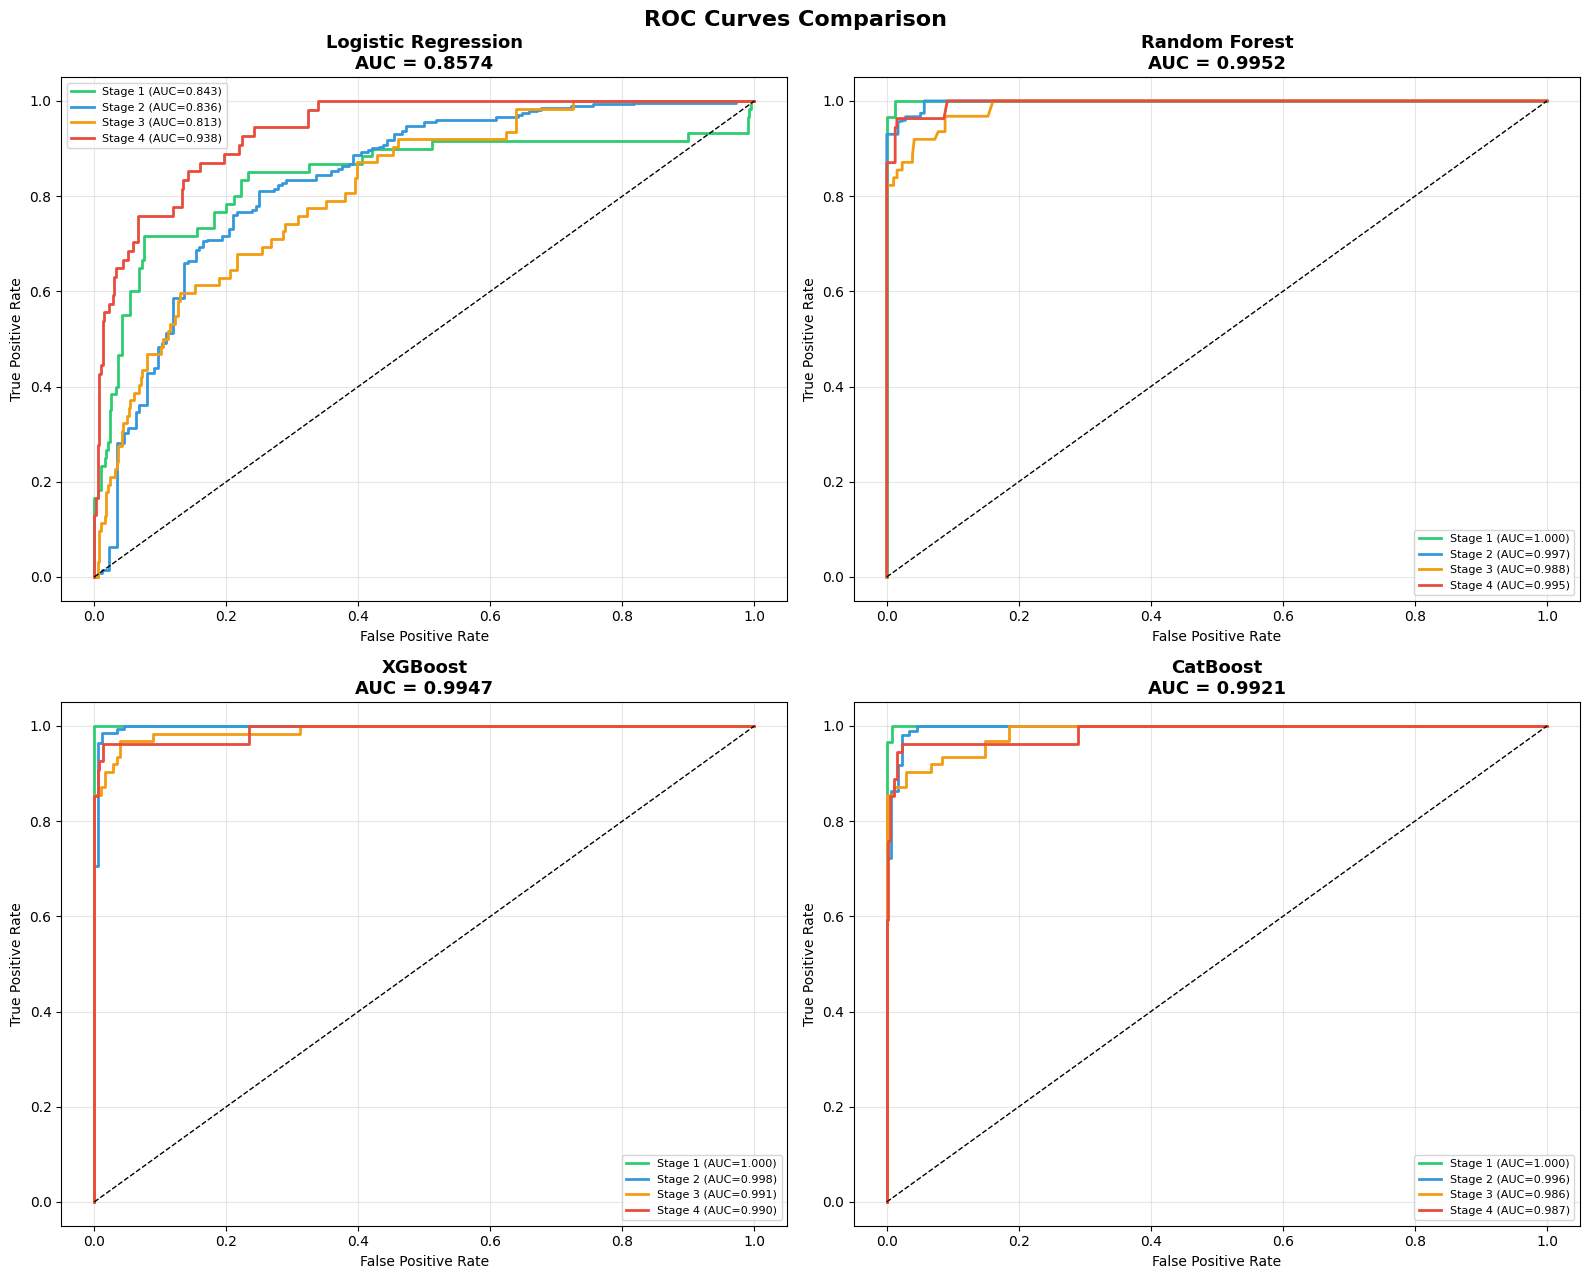

✅ Saved: four_models_roc_curves.png


In [66]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Check if 'four_results' is defined, if not, inform the user
if 'four_results' not in globals():
    print("Error: 'four_results' is not defined. Please ensure the model training cell (Cell ID: voSHzt7Z5txV) has been executed.")
    # Create an empty dictionary to prevent further NameErrors, but this will result in an empty plot.
    # The user needs to run the previous cell for meaningful results.
    four_results = {}

classes = np.unique(y_test)
n_classes = len(classes)

# Class names
if "stage_names" in globals() and len(stage_names) == n_classes:
    class_names = stage_names
else:
    class_names = [str(c) for c in classes]

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Binary case returns one column -> convert to two columns
if n_classes == 2:
    y_test_bin = np.column_stack((1 - y_test_bin[:, 0], y_test_bin[:, 0]))

colors = [
    "#2ecc71",
    "#3498db",
    "#f39c12",
    "#e74c3c",
    "#8e44ad",
    "#1abc9c",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

# Only proceed with plotting if four_results is not empty
if four_results:
    for i, (name, r) in enumerate(four_results.items()):

        probs = r["y_prob"]

        for k in range(n_classes):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, k],
                probs[:, k]
            )

            auc = roc_auc_score(
                y_test_bin[:, k],
                probs[:, k]
            )

            axes[i].plot(
                fpr,
                tpr,
                lw=2,
                color=colors[k],
                label=f"{class_names[k]} (AUC={auc:.3f})"
            )

        # Overall AUC
        if n_classes == 2:
            overall_auc = roc_auc_score(y_test, probs[:, 1])
        else:
            overall_auc = roc_auc_score(
                y_test,
                probs,
                multi_class="ovr",
                average="macro",
            )

        axes[i].plot([0, 1], [0, 1], "k--", lw=1)

        axes[i].set_title(
            f"{name}\nAUC = {overall_auc:.4f}",
            fontsize=13,
            fontweight="bold",
        )

        axes[i].set_xlabel("False Positive Rate")
        axes[i].set_ylabel("True Positive Rate")

        axes[i].legend(fontsize=8)

        axes[i].grid(alpha=0.3)

    plt.suptitle(
        "ROC Curves Comparison",
        fontsize=16,
        fontweight="bold",
    )

    plt.tight_layout()

    plt.savefig("four_models_roc_curves.png", dpi=150)

    plt.show()

    print("✅ Saved: four_models_roc_curves.png")
else:
    print("No ROC curves generated because 'four_results' was not populated.")
    plt.close(fig) # Close the empty figure if no results to plot


In [67]:
# ==============================
# Cell 31: Final Model Comparison
# Works for Binary & Multiclass
# ==============================

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

rows = []

# Detect classes
classes = np.unique(y_test)
n_classes = len(classes)

# Determine class names
if "stage_names" in globals() and len(stage_names) == n_classes:
    class_names = stage_names
else:
    class_names = [str(c) for c in classes]

for name, r in four_results.items():

    report = classification_report(
        y_test,
        r["y_pred"],
        labels=classes,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    row = {
        "Model": name,
        "Test Accuracy (%)": round(r["accuracy"] * 100, 2),
        "AUC-ROC": round(r["auc"], 4) if not np.isnan(r["auc"]) else np.nan,
        "CV Accuracy (%)": round(r["cv_mean"] * 100, 2),
        "CV Std (%)": round(r["cv_std"] * 100, 2),
    }

    # Add F1-score for every detected class
    for cls in class_names:
        row[f"{cls} F1"] = round(report[cls]["f1-score"], 4)

    row["Macro F1"] = round(report["macro avg"]["f1-score"], 4)
    row["Weighted F1"] = round(report["weighted avg"]["f1-score"], 4)

    rows.append(row)

# Create summary table
final_df = (
    pd.DataFrame(rows)
    .sort_values("Test Accuracy (%)", ascending=False)
    .reset_index(drop=True)
)

final_df.index += 1

print("=" * 100)
print("🏆 FINAL MODEL COMPARISON")
print("=" * 100)
print(final_df)

print("\n🥇 Best Model")
print(f"Model        : {final_df.iloc[0]['Model']}")
print(f"Accuracy     : {final_df.iloc[0]['Test Accuracy (%)']:.2f}%")
print(f"AUC-ROC      : {final_df.iloc[0]['AUC-ROC']:.4f}")
print(f"Macro F1     : {final_df.iloc[0]['Macro F1']:.4f}")

print("\n📁 Generated Files")

files = [
    "four_models_confusion_matrices.png",
    "four_models_performance_by_stage.png",
    "four_models_accuracy_comparison.png",
    "four_models_roc_curves.png",
]

for file in files:
    print(f"✅ {file}")

🏆 FINAL MODEL COMPARISON
                 Model  Test Accuracy (%)  AUC-ROC  CV Accuracy (%)  \
1             CatBoost              96.42   0.9921            93.45   
2              XGBoost              96.20   0.9947            92.78   
3        Random Forest              95.30   0.9952            92.05   
4  Logistic Regression              71.36   0.8574            71.74   

   CV Std (%)  Stage 1 F1  Stage 2 F1  Stage 3 F1  Stage 4 F1  Macro F1  \
1        0.58      0.9831      0.9855      0.9000      0.9057    0.9435   
2        0.53      0.9831      0.9818      0.8908      0.9174    0.9432   
3        0.33      0.9744      0.9763      0.8667      0.9074    0.9312   
4        1.84      0.2778      0.8288      0.3505      0.6600    0.5293   

   Weighted F1  
1       0.9636  
2       0.9615  
3       0.9525  
4       0.6681  

🥇 Best Model
Model        : CatBoost
Accuracy     : 96.42%
AUC-ROC      : 0.9921
Macro F1     : 0.9435

📁 Generated Files
✅ four_models_confusion_matrices.pn

### Confusion Matrix for the Best Model (CatBoost)

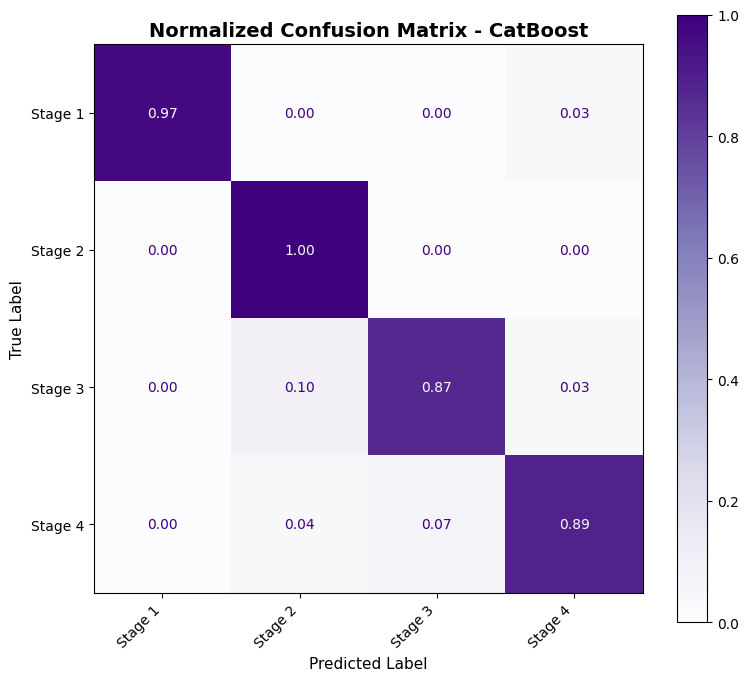

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

best_model_name = "CatBoost"
best_model_results = four_results[best_model_name]

# Predictions
y_pred_best = best_model_results["y_pred"]

# Detect classes
classes = np.unique(y_test)

# Determine display labels
if "stage_names" in globals() and len(stage_names) == len(classes):
    labels = stage_names
else:
    labels = [str(c) for c in classes]

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    labels=classes,
    display_labels=labels,
    cmap="Purples",
    normalize="true",
    values_format=".2f",
    ax=ax
)

ax.set_title(
    f"Normalized Confusion Matrix - {best_model_name}",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Per-Class Performance Metrics (Precision, Recall, F1-Score) for the Best Model (CatBoost)

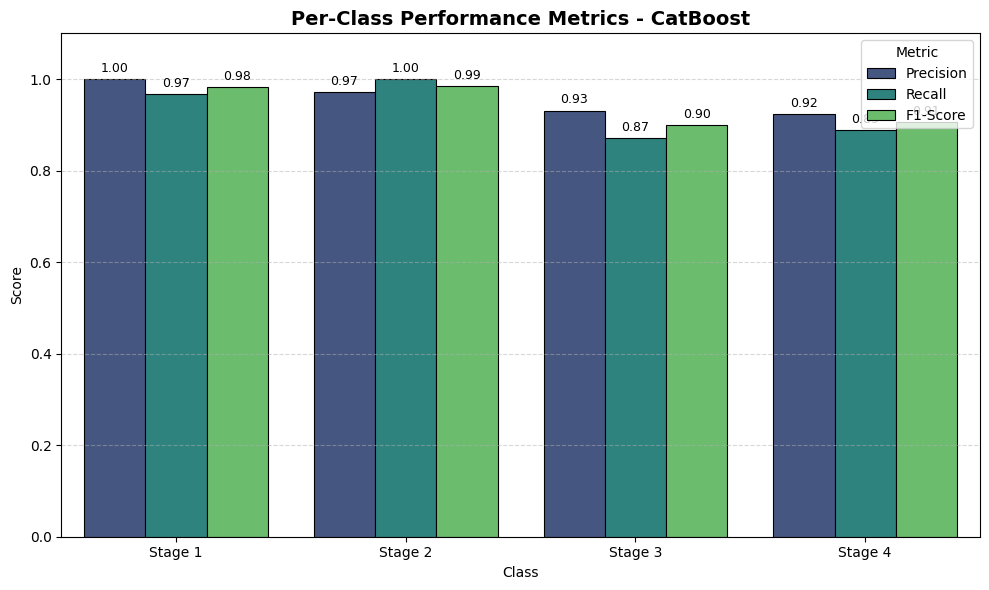

In [69]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = ["precision", "recall", "f1-score"]

# Detect classes
classes = np.unique(y_test)

# Determine display names
if "stage_names" in globals() and len(stage_names) == len(classes):
    class_names = stage_names
else:
    class_names = [str(c) for c in classes]

# Classification report
report_best_model = classification_report(
    y_test,
    y_pred_best,
    labels=classes,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Prepare plotting dataframe
plot_data = []

for cls in class_names:
    for metric in metrics_to_plot:
        plot_data.append({
            "Class": cls,
            "Metric": metric.title(),
            "Score": report_best_model[cls][metric]
        })

df_plot = pd.DataFrame(plot_data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_plot,
    x="Class",
    y="Score",
    hue="Metric",
    palette="viridis",
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=3)

ax.set_ylim(0, 1.1)

ax.set_title(
    f"Per-Class Performance Metrics - {best_model_name}",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Class")
ax.set_ylabel("Score")

ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.legend(title="Metric")

plt.tight_layout()
plt.show()

In [70]:
import joblib
import os

In [71]:
# Create folder to store models
os.makedirs("saved_models", exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


In [72]:
# Find best model based on test accuracy
best_model_name = max(
    four_results,
    key=lambda x: four_results[x]["accuracy"]
)

best_model = four_results[best_model_name]["model"]

print("Best Model :", best_model_name)
print("Accuracy   :", round(four_results[best_model_name]["accuracy"]*100,2),"%")

Best Model : CatBoost
Accuracy   : 96.42 %


In [73]:
joblib.dump(
    best_model,
    "saved_models/copd_model.pkl"
)

print("COPD model saved successfully!")

COPD model saved successfully!
